# Stacked ATAC-seq Heatmap


In [2]:
import gzip, json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"]  = 42

BASE = "/coh_labs/mvandenbrink/users/pkaur/6_tff1/2_bulk_atac/atacseq_pipeline/0_broadpeak"
MATRIX_FILE = os.path.join(BASE, "3_global_heatmap/global.mat.gz")

# ── Read matrix ──────────────────────────────────────────────────────────
with gzip.open(MATRIX_FILE, "rt") as fh:
    header = json.loads(fh.readline().strip().lstrip("@"))
    rows = []
    for line in fh:
        fields = line.strip().split("\t")
        rows.append([float(v) if v != "nan" else np.nan for v in fields[6:]])

data = np.array(rows)
bounds = header["sample_boundaries"]
n_bins = bounds[1] - bounds[0]

gfp  = np.nan_to_num(data[:, bounds[0]:bounds[1]], nan=0.0)
tff1 = np.nan_to_num(data[:, bounds[1]:bounds[2]], nan=0.0)

# Sort by GFP mean (descending), shared 99th-pct color cap
order = np.argsort(gfp.mean(axis=1))[::-1]
gfp, tff1 = gfp[order], tff1[order]
pos = np.concatenate([gfp.ravel(), tff1.ravel()])
vmax = np.percentile(pos[pos > 0], 99) if (pos > 0).any() else 5.0

# Profile curves
up, down = header["upstream"][0], header["downstream"][0]
x_kb = np.linspace(-up/1000, down/1000, n_bins)
n_peaks = gfp.shape[0]

print(f"Peaks: {n_peaks:,}  |  Bins: {n_bins}  |  vmax: {vmax:.4f}")

Peaks: 6,452  |  Bins: 400  |  vmax: 0.1481


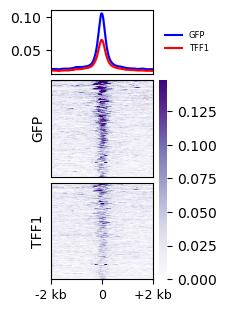

In [3]:
%matplotlib inline
fig = plt.figure(figsize=(1.5, 3.5))
gs = gridspec.GridSpec(3, 2, height_ratios=[2, 3, 3],
                       width_ratios=[20, 1.5], hspace=0.07, wspace=0.12)
# ── Profile ──────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for arr, color, label in [(gfp, "Blue", "GFP"), (tff1, "Red", "TFF1")]:
    mu = arr.mean(axis=0)
    se = arr.std(axis=0) / np.sqrt(n_peaks)
    ax.fill_between(x_kb, mu - se, mu + se, color=color, alpha=0.15)
    ax.plot(x_kb, mu, color=color, lw=1.5, label=label)
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=6, frameon=False)
ax.set_xlim(x_kb[0], x_kb[-1])
ax.tick_params(axis="x", bottom=False, labelbottom=False)
# ── Heatmaps ─────────────────────────────────────────────────────────────
kw = dict(aspect="auto", cmap="Purples", vmin=0, vmax=vmax,
          extent=[x_kb[0], x_kb[-1], n_peaks, 0], interpolation="none")
for i, (arr, name) in enumerate([(gfp, "GFP"), (tff1, "TFF1")], start=1):
    ax = fig.add_subplot(gs[i, 0])
    im = ax.imshow(arr, **kw)
    ax.set_ylabel(name, fontsize=10)
    ax.tick_params(axis="y", left=False, labelleft=False)
    if i == 1:
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
    else:
        ax.set_xticks([-2, 0, 2])
        ax.set_xticklabels(["-2 kb", "0", "+2 kb"], fontsize=9)
# ── Colorbar ─────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, cax=fig.add_subplot(gs[1:, 1]))
cbar.outline.set_visible(False)
plt.show()
for ext in ["pdf"]:
    fig.savefig(f"stacked_accessibility_heatmap.{ext}", dpi=300, bbox_inches="tight")